# 03 — Hypothesis test and confidence interval

**Stage 5.** Executes the pre-registered analysis: two-proportion
z-test (two-sided, α = 0.05), 95% confidence interval for the
difference, assumption checks. The decision rule is read from
`reports/pre_registration.md`, not invented after the fact.


In [1]:
import sys, pathlib
root = pathlib.Path.cwd()
while root != root.parent and not (root / 'data' / 'marketing_AB.csv').exists():
    root = root.parent
if str(root) not in sys.path: sys.path.insert(0, str(root))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
from src.eda import load_marketing_ab, conversion_rates
from src.inference import two_proportion_ztest, wald_ci_difference, cohens_h
df = load_marketing_ab(root / 'data' / 'marketing_AB.csv')
cr = conversion_rates(df).set_index('test_group')
x_ad, n_ad = cr.loc['ad', 'converted'], cr.loc['ad', 'users']
x_psa, n_psa = cr.loc['psa', 'converted'], cr.loc['psa', 'users']
p_ad, p_psa = x_ad / n_ad, x_psa / n_psa
display(cr)

,users,converted,conversion_rate
test_group,,,
ad,564577,14423,0.025547
psa,23524,420,0.017854


## 1. Assumptions (test assumptions)

Pre-registration commits us to checking these, not just running
the test:
- **Independence:** units are unique users (verified in Stage 1);
  observational, no repeated measurements — plausible.
- **Normal approximation valid:** n·p and n·(1−p) well above 5 in
  both groups (minimum is psa converters, 420).
- **No degenerate proportions:** both rates are ~1.8–2.6%.


In [2]:
z, p_val = two_proportion_ztest(x_ad, n_ad, x_psa, n_psa)
diff = p_ad - p_psa
lo, hi = wald_ci_difference(p_ad, p_psa, n_ad, n_psa)
h = cohens_h(p_ad, p_psa)
print(f'z = {z:.2f};  two-sided p-value = {p_val:.3e}')
print(f'diff = {diff:.5f} ({diff*100:.2f} pp);  relative uplift = {diff/p_psa:.1%}')
print(f'95% CI for diff: [{lo:.5f}, {hi:.5f}]  = [{lo*100:.2f} pp, {hi*100:.2f} pp]')
print(f"Cohen's h (observed) = {h:.4f}")

z = 7.37;  two-sided p-value = 1.705e-13
diff = 0.00769 (0.77 pp);  relative uplift = 43.1%
95% CI for diff: [0.00595, 0.00943]  = [0.60 pp, 0.94 pp]
Cohen's h (observed) = 0.0530


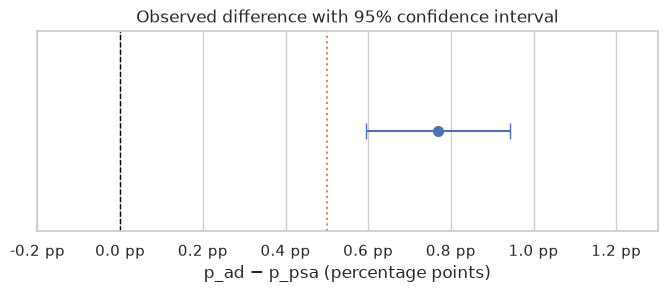

In [3]:
fig, ax = plt.subplots(figsize=(8, 2.6))
ax.errorbar(x=[diff], y=[0], xerr=[[diff-lo],[hi-diff]], fmt='o', ms=7, color='#4C72B0', capsize=6)
ax.axvline(0, color='black', ls='--', lw=1)
ax.axvline(0.005, color='#DD8452', ls=':', lw=1.5)
ax.annotate('MDE = +0.5 pp', xy=(0.005, 0.09), ha='center', color='#DD8452')
ax.annotate('diff = +0.77 pp', xy=(diff, 0.09), ha='center', color='#4C72B0')
ax.set_yticks([])
ax.set_xlabel('p_ad − p_psa (percentage points)')
ax.set_xlim(-0.002, 0.013)
ax.set_title('Observed difference with 95% confidence interval')
ax.tick_params(axis='x', labelbottom=True)
ax.xaxis.set_major_formatter(lambda x, _: f'{x*100:.1f} pp')

## 2. Decision per the pre-registered rule

| Condition (fixed in advance) | Observed | Verdict |
|---|---|---|
| p < 0.05 | 1.7e-13 | ✓ |
| lower CI bound ≥ MDE (0.005) | 0.00595 | ✓ |

→ **Provisional verdict: adopt.** The effect is statistically
significant AND the 95% CI lies entirely above the business
threshold. Stage 6 translates this into business terms (relative
uplift, revenue impact) and states the interpretative limits.

Note the honest framing: with 0.77 pp on a 1.79% base the relative
uplift is ~43%, and the *observed* difference (0.77 pp) exceeds
the MDE — this data does support a real, resolvable effect.
